# **TP3 (Parte 2 e 3):**
## *Vetorização de Variáveis Categóricas*

In [84]:
# Instalação das bibliotecas necessárias
!pip install -q pandas scikit-learn category_encoders

# Imports
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

## Importação do Dataset

In [85]:
# Importando o dataset que está na pasta 'dataset'
df = pd.read_csv('dataset/toy_dataset.csv')

# Exibindo o dataframe
df

,Dia,Aspecto,Temperatura,Umidade,Vento,Jogar_Tenis
0,D1,Sol,Quente,Elevada,Fraco,Não
1,D2,Sol,Quente,Elevada,Forte,Não
2,D3,Nuvens,Quente,Elevada,Fraco,Sim
3,D4,Chuva,Ameno,Elevada,Fraco,Sim
4,D5,Chuva,Fresco,Normal,Fraco,Sim
5,D6,Chuva,Fresco,Normal,Forte,Não
6,D7,Nuvens,Fresco,Normal,Fraco,Sim
7,D8,Sol,Ameno,Elevada,Fraco,Não
8,D9,Sol,Fresco,Normal,Fraco,Sim
9,D10,Chuva,Ameno,Normal,Forte,Sim


## Questão 5 - One-Hot Encoding

In [86]:
# Aplicando One-Hot Encoding nas variáveis categóricas
onehot = pd.get_dummies(df[['Aspecto', 'Temperatura', 'Umidade', 'Vento']])

# Juntando com as colunas 'Dia' e 'Jogar_Tenis'
df_onehot = pd.concat([df[['Dia', 'Jogar_Tenis']], onehot], axis=1)

df_onehot

,Dia,Jogar_Tenis,Aspecto_Chuva,Aspecto_Nuvens,Aspecto_Sol,Temperatura_Ameno,Temperatura_Fresco,Temperatura_Quente,Umidade_Elevada,Umidade_Normal,Vento_Forte,Vento_Fraco
0,D1,Não,False,False,True,False,False,True,True,False,False,True
1,D2,Não,False,False,True,False,False,True,True,False,True,False
2,D3,Sim,False,True,False,False,False,True,True,False,False,True
3,D4,Sim,True,False,False,True,False,False,True,False,False,True
4,D5,Sim,True,False,False,False,True,False,False,True,False,True
5,D6,Não,True,False,False,False,True,False,False,True,True,False
6,D7,Sim,False,True,False,False,True,False,False,True,False,True
7,D8,Não,False,False,True,True,False,False,True,False,False,True
8,D9,Sim,False,False,True,False,True,False,False,True,False,True
9,D10,Sim,True,False,False,True,False,False,False,True,True,False


## Questão 6 - Dummy Encoding

In [87]:
# Aplicando Dummy Encoding (One-Hot com drop da primeira categoria de cada variável)
dummy = pd.get_dummies(df[['Aspecto', 'Temperatura', 'Umidade', 'Vento']], drop_first=True)

df_dummy = pd.concat([df[['Dia', 'Jogar_Tenis']], dummy], axis=1)

df_dummy

,Dia,Jogar_Tenis,Aspecto_Nuvens,Aspecto_Sol,Temperatura_Fresco,Temperatura_Quente,Umidade_Normal,Vento_Fraco
0,D1,Não,False,True,False,True,False,True
1,D2,Não,False,True,False,True,False,False
2,D3,Sim,True,False,False,True,False,True
3,D4,Sim,False,False,False,False,False,True
4,D5,Sim,False,False,True,False,True,True
5,D6,Não,False,False,True,False,True,False
6,D7,Sim,True,False,True,False,True,True
7,D8,Não,False,True,False,False,False,True
8,D9,Sim,False,True,True,False,True,True
9,D10,Sim,False,False,False,False,True,False


## Questão 7 - Effect Encoding

In [88]:
# Aplicando Effect Encoding (também conhecido como Sum Encoding)
effect_encoder = ce.SumEncoder(cols=['Aspecto', 'Temperatura', 'Umidade', 'Vento'])

df_effect_encoded = effect_encoder.fit_transform(df[['Aspecto', 'Temperatura', 'Umidade', 'Vento']])

df_effect = pd.concat([df[['Dia', 'Jogar_Tenis']], df_effect_encoded], axis=1)

df_effect

,Dia,Jogar_Tenis,Aspecto_0,Aspecto_1,Temperatura_0,Temperatura_1,Umidade_0,Vento_0
0,D1,Não,1.0,0.0,1.0,0.0,1.0,1.0
1,D2,Não,1.0,0.0,1.0,0.0,1.0,-1.0
2,D3,Sim,0.0,1.0,1.0,0.0,1.0,1.0
3,D4,Sim,-1.0,-1.0,0.0,1.0,1.0,1.0
4,D5,Sim,-1.0,-1.0,-1.0,-1.0,-1.0,1.0
5,D6,Não,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
6,D7,Sim,0.0,1.0,-1.0,-1.0,-1.0,1.0
7,D8,Não,1.0,0.0,0.0,1.0,1.0,1.0
8,D9,Sim,1.0,0.0,-1.0,-1.0,-1.0,1.0
9,D10,Sim,-1.0,-1.0,0.0,1.0,-1.0,-1.0


## Questão 8 - Comparação dos Métodos

In [89]:
pd.set_option('display.max_colwidth', None)

# Comparando os métodos
comparacao = pd.DataFrame({
    'Método': ['One-Hot Encoding', 'Dummy Encoding', 'Effect Encoding'],
    'Total de Colunas Geradas': [df_onehot.shape[1] - 2, df_dummy.shape[1] - 2, df_effect.shape[1] - 2],
    'Descrição': [
        'Cria uma coluna para cada categoria, preservando totalmente a informação, porém aumentando dimensionalidade.',
        'Remove uma coluna por variável categórica para evitar multicolinearidade, assumindo que uma categoria é referência.',
        'Codifica as categorias como desvios da média, onde a soma dos efeitos é zero, mantendo a interpretação estatística dos efeitos.'
    ]
})

comparacao

,Método,Total de Colunas Geradas,Descrição
0,One-Hot Encoding,10,"Cria uma coluna para cada categoria, preservando totalmente a informação, porém aumentando dimensionalidade."
1,Dummy Encoding,6,"Remove uma coluna por variável categórica para evitar multicolinearidade, assumindo que uma categoria é referência."
2,Effect Encoding,6,"Codifica as categorias como desvios da média, onde a soma dos efeitos é zero, mantendo a interpretação estatística dos efeitos."


## Questão 11 - Feature Hashing

Dataset original + Feature Hashing:
        cor tamanho       forma  hash_0  hash_1  hash_2  hash_3
0  vermelho       P    circular    -1.0     0.0     0.0     0.0
1      azul       M    quadrado     0.0     0.0     2.0     1.0
2     verde       G  triangular     0.0     0.0     0.0    -1.0
3  vermelho       G    circular    -1.0     2.0     0.0     0.0
4      azul       P  triangular     0.0    -1.0     0.0     0.0


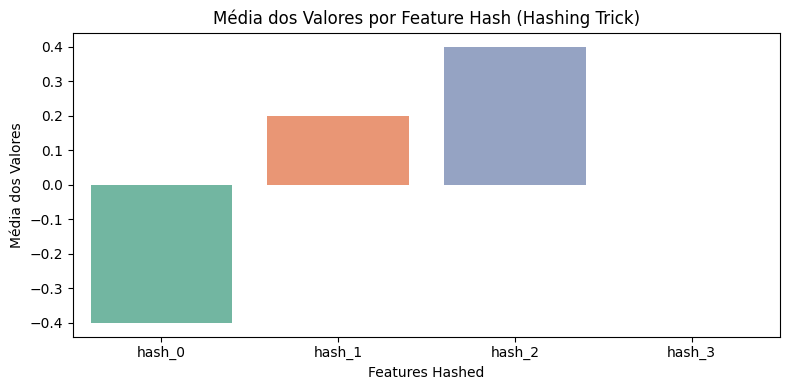

In [90]:
from sklearn.feature_extraction import FeatureHasher

def preparar_dataset():
    return pd.DataFrame({
        'cor': ['vermelho', 'azul', 'verde', 'vermelho', 'azul'],
        'tamanho': ['P', 'M', 'G', 'G', 'P'],
        'forma': ['circular', 'quadrado', 'triangular', 'circular', 'triangular']
    })

def aplicar_feature_hashing(df, n_features=4):
    hasher = FeatureHasher(n_features=n_features, input_type='string')
    hash_array = hasher.transform(df.astype(str).values).toarray()
    colunas_hash = [f'hash_{i}' for i in range(n_features)]
    return pd.DataFrame(hash_array, columns=colunas_hash)

def plotar_media_hash(df_hash):
    medias = df_hash.mean()
    plt.figure(figsize=(8, 4))
    sns.barplot(x=medias.index, y=medias.values, palette='Set2', hue=medias.index, legend=False)
    plt.title('Média dos Valores por Feature Hash (Hashing Trick)')
    plt.xlabel('Features Hashed')
    plt.ylabel('Média dos Valores')
    plt.tight_layout()
    plt.show()

def main_feature_hashing():
    df = preparar_dataset()
    df_hash = aplicar_feature_hashing(df)
    df_visual = pd.concat([df, df_hash], axis=1)

    print("Dataset original + Feature Hashing:")
    print(df_visual)

    plotar_media_hash(df_hash)

main_feature_hashing()

## Questão 12 - Bin Counting

Dataset original + Bin Counting:
        cor tamanho       forma  cor_bin_count  tamanho_bin_count  \
0  vermelho       P    circular              2                  2   
1      azul       M    quadrado              2                  1   
2     verde       G  triangular              1                  2   
3  vermelho       G    circular              2                  2   
4      azul       P  triangular              2                  2   

   forma_bin_count  
0                2  
1                1  
2                2  
3                2  
4                2  


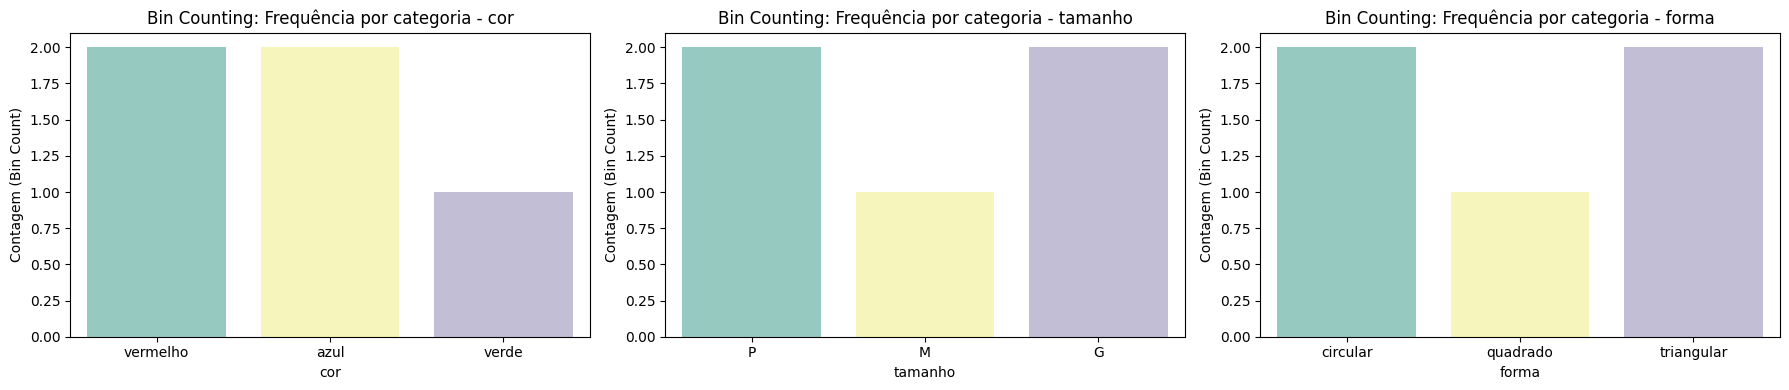

In [91]:
def preparar_dataset():
    return pd.DataFrame({
        'cor': ['vermelho', 'azul', 'verde', 'vermelho', 'azul'],
        'tamanho': ['P', 'M', 'G', 'G', 'P'],
        'forma': ['circular', 'quadrado', 'triangular', 'circular', 'triangular']
    })

def aplicar_bin_count(df):
    df_bin = df.copy()
    for coluna in df.columns:
        contagem = df[coluna].value_counts()
        df_bin[f'{coluna}_bin_count'] = df[coluna].map(contagem)
    return df_bin

def plotar_frequencias_bin_count(df_bin, colunas_originais):
    fig, axes = plt.subplots(1, len(colunas_originais), figsize=(6*len(colunas_originais), 4))
    if len(colunas_originais) == 1:
        axes = [axes]
    for ax, coluna in zip(axes, colunas_originais):
        sns.barplot(x=df_bin[coluna], y=df_bin[f'{coluna}_bin_count'],
                    palette='Set3', hue=df_bin[coluna], legend=False, ax=ax)
        ax.set_title(f'Bin Counting: Frequência por categoria - {coluna}')
        ax.set_xlabel(coluna)
        ax.set_ylabel('Contagem (Bin Count)')
    plt.tight_layout()
    plt.show()

def main_bin_counting():
    df = preparar_dataset()
    df_bin = aplicar_bin_count(df)

    print("Dataset original + Bin Counting:")
    print(df_bin)

    plotar_frequencias_bin_count(df_bin, df.columns)

main_bin_counting()